<h5></h5>

In [1]:
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import(classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

tf.random.set_seed(42)
np.random.seed(42)

<h5>Step 2: Load prepared data</h5>

In [2]:
train_df = pd.read_csv('diabetes_train.csv')
val_df = pd.read_csv('diabetes_val.csv')
test_df = pd.read_csv('diabetes_test.csv')

X_train = train_df.drop(columns=['Outcome']).values.astype(np.float32)
y_train = train_df['Outcome'].values.astype(np.float32)

X_val = val_df.drop(columns = ['Outcome']).values.astype(np.float32)
y_val = val_df['Outcome'].values.astype(np.float32)

X_test =test_df.drop(columns=['Outcome']).values.astype(np.float32)
y_test = test_df['Outcome'].values.astype(np.float32)

print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")

Train: (537, 14)
Val: (115, 14)
Test: (116, 14)
Number of features: 14


In [3]:
with open('diabetes_metadata.json') as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
train_medians = metadata['train_medians']
scaler_mean = np.array(metadata['scaler_mean'],dtype=np.float32)
scaler_scale = np.array(metadata['scaler_scale'],dtype=np.float32)

print(f"Loaded metadata for {len(feature_cols)} features")
scaler_scale

Loaded metadata for 14 features


array([3.3820171e+00, 2.9510159e+01, 1.2327506e+01, 9.1778965e+00,
       8.1450020e+01, 6.6842527e+00, 3.2427591e-01, 1.1811565e+01,
       1.3876493e+03, 4.3319400e+02, 4.3056646e-01, 4.8798811e-01,
       4.8535880e-01, 4.5137453e-01], dtype=float32)

In [4]:
def build_ann(n_features):
    inputs = keras.Input(shape=(n_features,), name='features')


    #block 1
    x = keras.layers.Dense(128,kernel_regularizer= keras.regularizers.l2(1e-4))(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    #block 2
    x = keras.layers.Dense(64,kernel_regularizer= keras.regularizers.l2(1e-4))(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.3)(x)                       

    #block 3
    x = keras.layers.Dense(32)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    #Output: a single probability
    outputs = keras.layers.Dense(1, activation = 'sigmoid', name = 'prob')(x)
    return keras.Model(inputs, outputs, name='DiabetesANN')

model = build_ann(X_train.shape[1])
model.summary()

Model: "DiabetesANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 14)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           1,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ prob (Dense)                         │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,737 (49.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [5]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=25,
        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5,patience=10,
        min_lr=1e-6, mode='max', verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_diabetes.keras', monitor='val_auc',
        save_best_only=True, mode='max', verbose=0
    ),
]

history = model.fit(
    X_train,y_train,
    epochs=300, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

print(f"\nEpochs run: {len(history.history['loss'])}")
print(f"\Best val AUC: {max(history.history['val_auc']):.4f}")

Epoch 1/300


<>:25: SyntaxWarning: invalid escape sequence '\B'
<>:25: SyntaxWarning: invalid escape sequence '\B'
C:\Users\ATZ COMPUTERS\AppData\Local\Temp\ipykernel_6488\2185311757.py:25: SyntaxWarning: invalid escape sequence '\B'
  print(f"\Best val AUC: {max(history.history['val_auc']):.4f}")


17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.6034 - auc: 0.5431 - loss: 0.7073 - precision: 0.4150 - recall: 0.3245 - val_accuracy: 0.6957 - val_auc: 0.7587 - val_loss: 0.6801 - val_precision: 0.5439 - val_recall: 0.7750 - learning_rate: 5.0000e-04
Epoch 2/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6518 - auc: 0.6577 - loss: 0.6337 - precision: 0.5033 - recall: 0.4096 - val_accuracy: 0.7478 - val_auc: 0.8020 - val_loss: 0.6346 - val_precision: 0.6170 - val_recall: 0.7250 - learning_rate: 5.0000e-04
Epoch 3/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7151 - auc: 0.7492 - loss: 0.5793 - precision: 0.6061 - recall: 0.5319 - val_accuracy: 0.7565 - val_auc: 0.8102 - val_loss: 0.5898 - val_precision: 0.6500 - val_recall: 0.6500 - learning_rate: 5.0000e-04
Epoch 4/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7542 - auc: 0.7978 - loss: 0.5354 - precision: 0.6628 - recall: 0.6064 - val_accuracy: 0.7652 - val_auc: 0.8185 - val_loss: 0.5528 - val

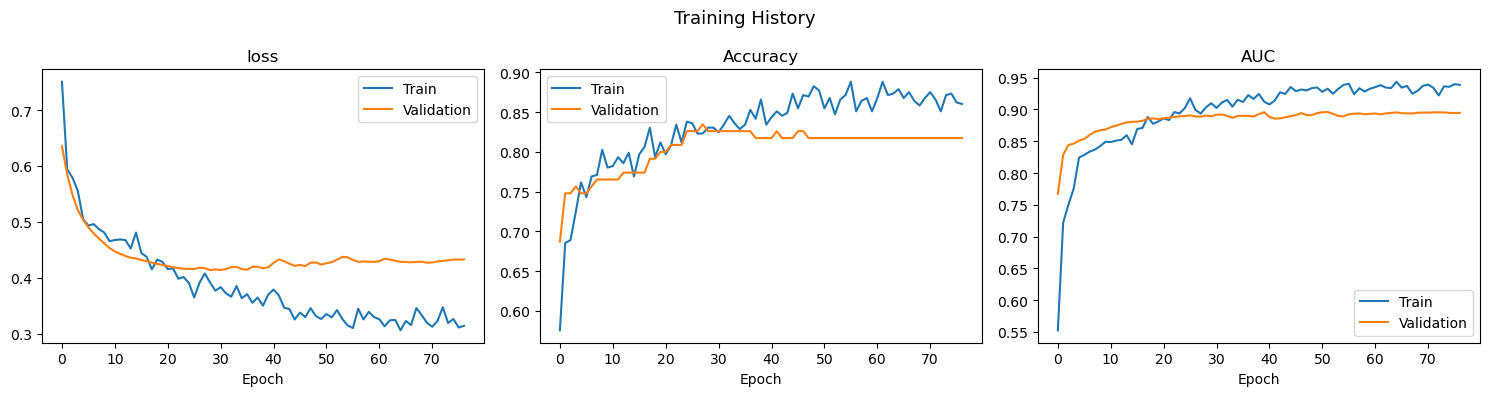

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='Validation')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()



In [8]:
model.load_weights('best_diabetes.keras')

test_results = model.evaluate(X_test, y_test, verbose=0)
for name, value in zip(model.metrics_names, test_results):
    print(f"{name:<12}: {value:.4f}")

loss        : 0.4458
compile_metrics: 0.7845


<h5>ROC Curve</h5>

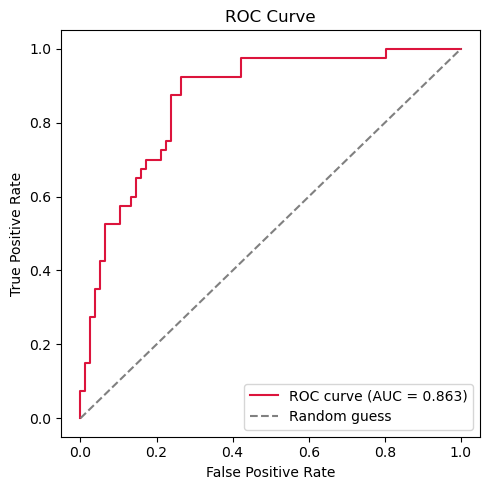

ROC-AUC: 0.8635


In [10]:
y_prob = model.predict(X_test, verbose=0).flatten()
auc_score = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)


plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, color='crimson', label = f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")

<h5>Clasification report and confusion matrix</h5>

## We use a plain 0.5 probability threshold to turn probabilities into yes/no predictions and see how the model actually did

              precision    recall  f1-score   support

 No Diabetes       0.83      0.84      0.84        76
    Diabetes       0.69      0.68      0.68        40

    accuracy                           0.78       116
   macro avg       0.76      0.76      0.76       116
weighted avg       0.78      0.78      0.78       116



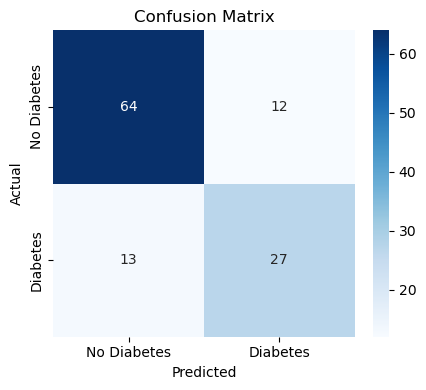

In [11]:
y_pred = (y_prob >= 0.5).astype(int)
import seaborn as sns
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['No Diabetes', 'Diabetes'],
           yticklabels=['No Diabetes', 'Diabetes'] )

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


<h1>Step 8: Save the trained model</h1>

# We save the model itself, plus the scaler and feature list, so that anyone can load them later and make predictions without retraining

In [12]:
model.save('diabetes_ann.keras')

with open('diabetes_inference_kit.pkl', 'wb') as f:
    pickle.dump({
        'scaler_mean': scaler_mean,
        'scaler_scale': scaler_scale,
        'feature_cols': feature_cols,
        'train_medians': train_medians,
    }, f)

print("Saved diabetes_ann.keras")
print("Saved diabetes_inference_ki.pkl")

    

Saved diabetes_ann.keras
Saved diabetes_inference_ki.pkl


In [16]:
def predict_patient(patient, model, feature_cols, scaler_mean, scaler_scale):
    patient = patient.copy()

# Add the same extra features we created during data preparation
    patient['Glucose_x_BMI'] = patient['Glucose'] * patient['BMI']
    patient['Age_x_BMI'] = patient['Age'] * patient['BMI']
    patient['impaired_glucose'] = float(patient['Glucose'] >= 100)
    patient['diabetic_glucose'] = float(patient['Glucose'] >= 126)
    patient['is_obese'] = float(patient['BMI'] >= 30)
    patient['older_patient'] = float(patient['Age'] >= 40)

    # Put the features in the exact same order the model expects
    row = np.array([patient[col] for col in feature_cols], dtype=np.float32)
    
    # Scale by hand: same formula the training data went through
    row_scaled = (row - scaler_mean)/ scaler_scale
    row_scaled = row_scaled.reshape(1, -1)
    
    probability = model.predict(row_scaled, verbose=0)[0][0]
    prediction = 'Diabetes' if probability >= 0.5 else 'No Diabetes'
    
    print(f"Probability of diabetes: {probability:.1%}")
    print(f"Prediction: {prediction}")

In [18]:
patient_1 = {
    'Pregnancies': 6, 'Glucose': 148, 'BloodPressure': 72, 'SkinThickness': 35,
    'Insulin': 0, 'BMI': 33.6, 'DiabetesPedigreeFunction': 0.625, 'Age': 50,
}
print("Patient 1 (actual: Diabetes)")
predict_patient(patient_1, model, feature_cols, scaler_mean, scaler_scale)

print()

patient_2 = {
    'Pregnancies': 1, 'Glucose': 85, 'BloodPressure': 66, 'SkinThickness': 29,
    'Insulin': 0, 'BMI': 26.6, 'DiabetesPedigreeFunction': 0.351, 'Age': 31,
}
print("Patient 2 (actual: No Diabetes)")
predict_patient(patient_2, model, feature_cols, scaler_mean, scaler_scale)

Patient 1 (actual: Diabetes)
Probability of diabetes: 11.2%
Prediction: No Diabetes

Patient 2 (actual: No Diabetes)
Probability of diabetes: 0.5%
Prediction: No Diabetes
